In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib

import load.load_dataset as ds
import load.load_net as nt
import load.nets.training as tr

import torch
from sklearn.metrics import roc_auc_score, roc_curve

# **Tuning of hyperparameters to train model**

In [2]:
def plot_roc(y_val, results):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)

    roc = roc_auc_score(y_val_labels, results['pred_proba'][0][:,1])
    fpr, tpr, _ = roc_curve(y_val_labels, results['pred_proba'][0][:,1])

    plt.figure(figsize=(6,6))
    plt.title(f'ROC AUC Curve - AUC: {roc:.4f}')
    plt.plot(fpr, tpr, color='blue', label='ROC')
    plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

In [3]:
def eval_net(dataset_name, model_name):
    
    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
    fig, ax = plt.subplots(1, 2, figsize = [12,5])
    ax[0].plot(axis, history['train_loss'], label='Train Loss')
    ax[0].plot(axis, history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss')
    ax[0].legend()

    ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
    ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
    ax[1].set_title('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')
    print(results['classification_report'][0])
    return results


## **ADULT**

In [4]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36177, 12) (8045, 12) (1000, 12)


### Adult - smallNN

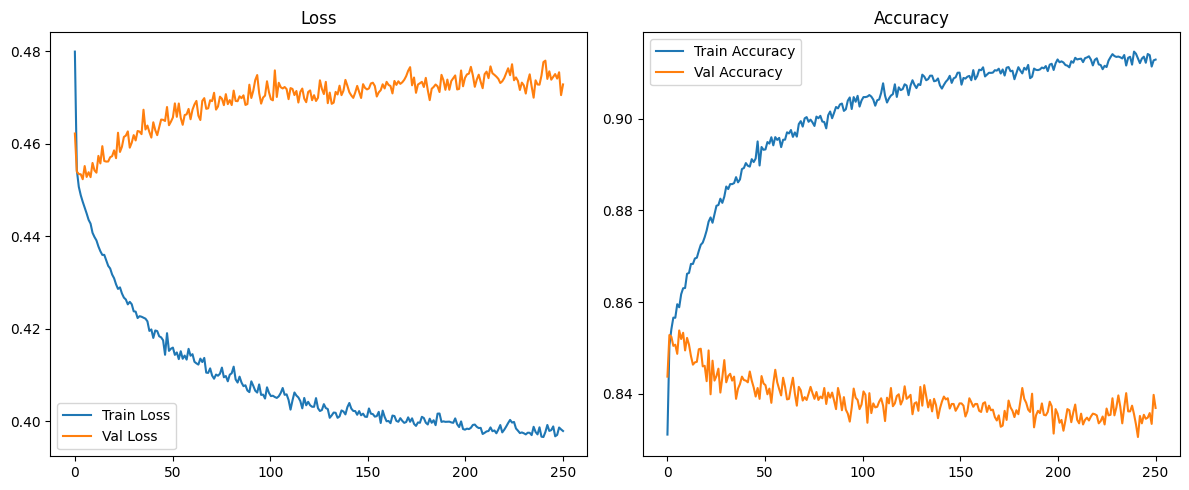

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6033
           1       0.69      0.63      0.66      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.77      0.78      8045
weighted avg       0.83      0.84      0.83      8045



In [5]:
result4 = eval_net(dataset_name, 'model4')

### Adult - RegularizedNN

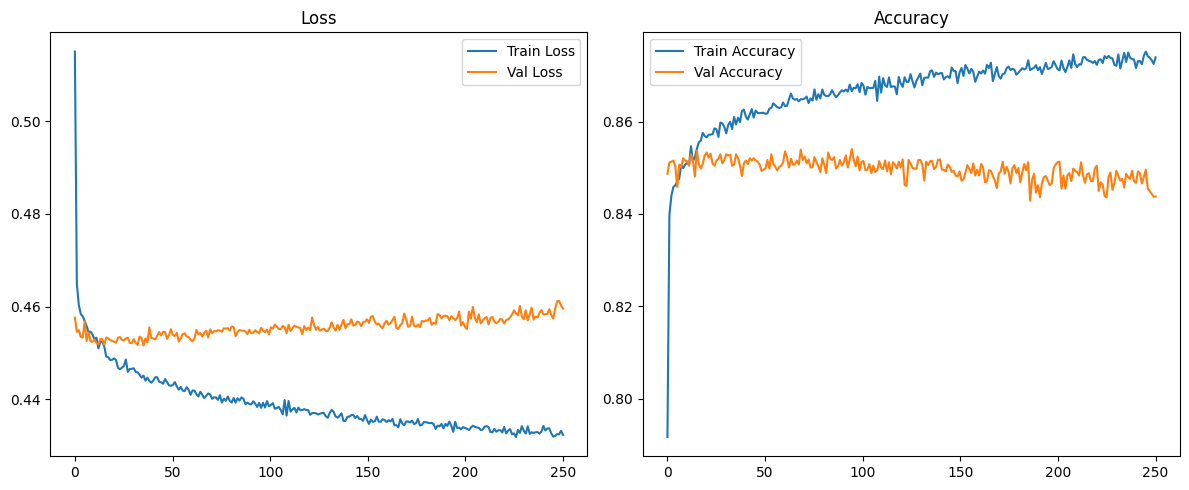

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      6033
           1       0.70      0.66      0.68      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.78      0.79      8045
weighted avg       0.84      0.84      0.84      8045



In [6]:
result5 = eval_net(dataset_name, 'model5')

### Adult - BottleneckNN

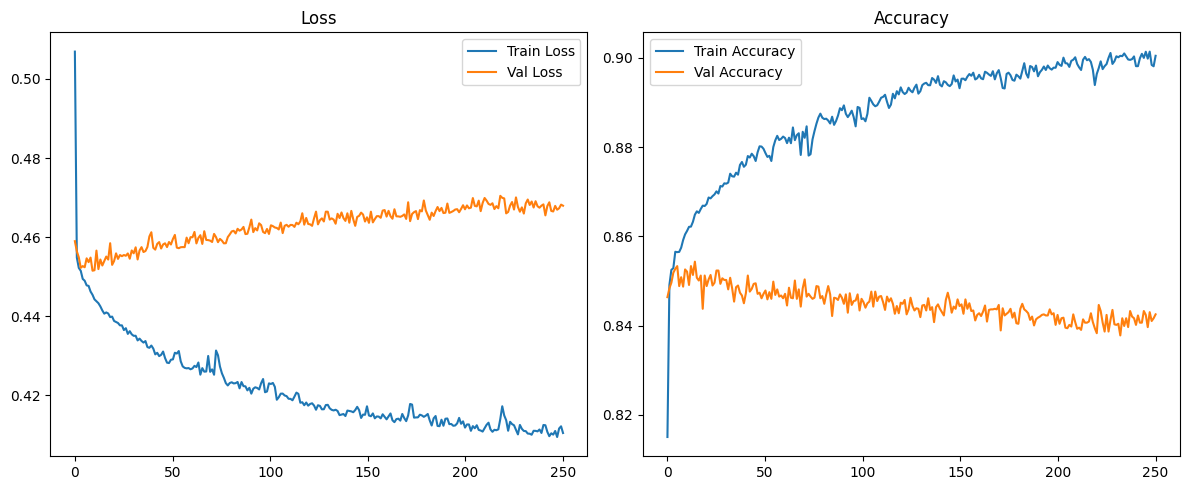

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      6033
           1       0.72      0.60      0.66      2012

    accuracy                           0.84      8045
   macro avg       0.80      0.76      0.78      8045
weighted avg       0.84      0.84      0.84      8045



In [7]:
result6 = eval_net(dataset_name, 'model6')

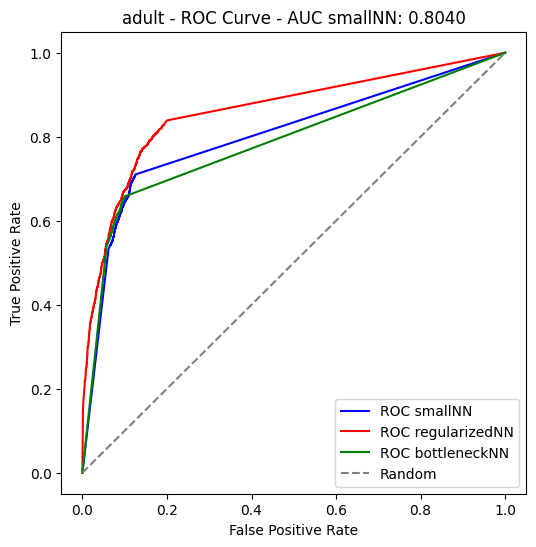

In [8]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])
    
roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])
    
roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve - AUC smallNN: {roc4:.4f}')
plt.plot(fpr4, tpr4, color='blue', label='ROC smallNN')
plt.plot(fpr5, tpr5, color='red', label='ROC regularizedNN')
plt.plot(fpr6, tpr6, color='green', label='ROC bottleneckNN')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## **BANK**

In [9]:
dataset_name = "bank"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36168, 14) (8043, 14) (1000, 14)


### Bank - SmallNN

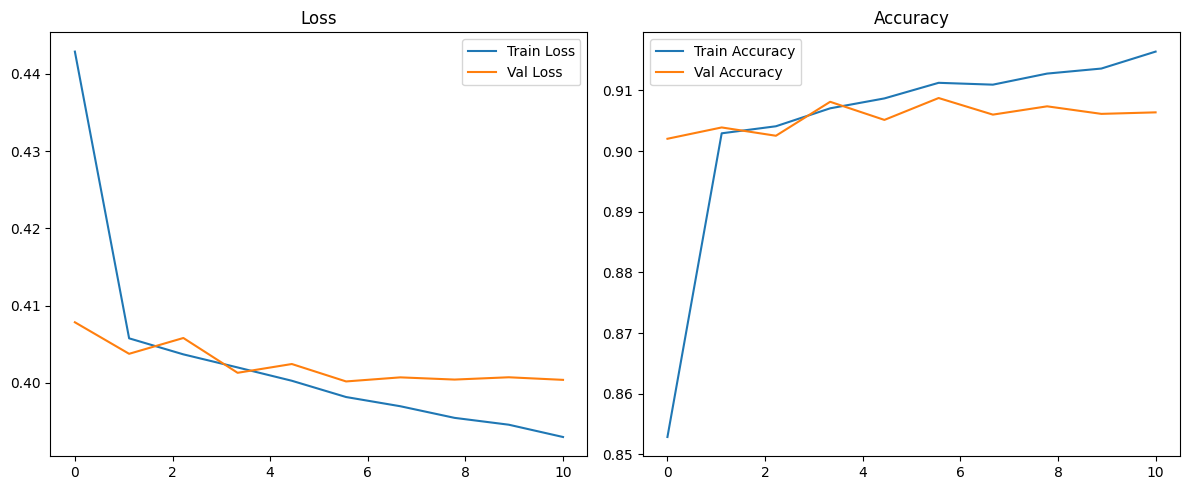

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7098
           1       0.62      0.51      0.56       945

    accuracy                           0.91      8043
   macro avg       0.78      0.73      0.75      8043
weighted avg       0.90      0.91      0.90      8043



In [10]:
result4 = eval_net(dataset_name, 'model4')

### Bank - RegularizedNN

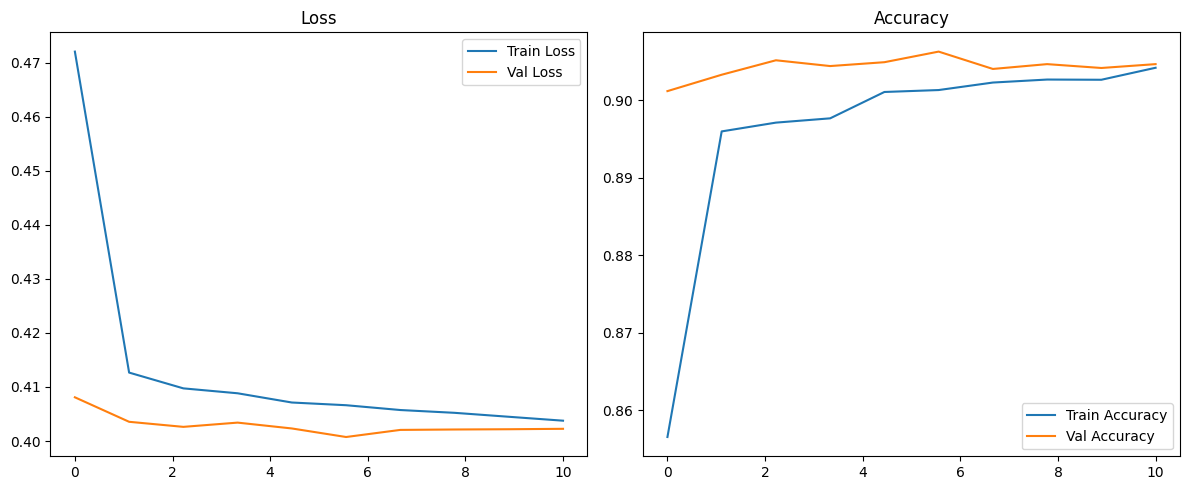

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7098
           1       0.65      0.41      0.50       945

    accuracy                           0.90      8043
   macro avg       0.79      0.69      0.72      8043
weighted avg       0.89      0.90      0.89      8043



In [11]:
result5 = eval_net(dataset_name, 'model5')

### Bank - BottleneckNN

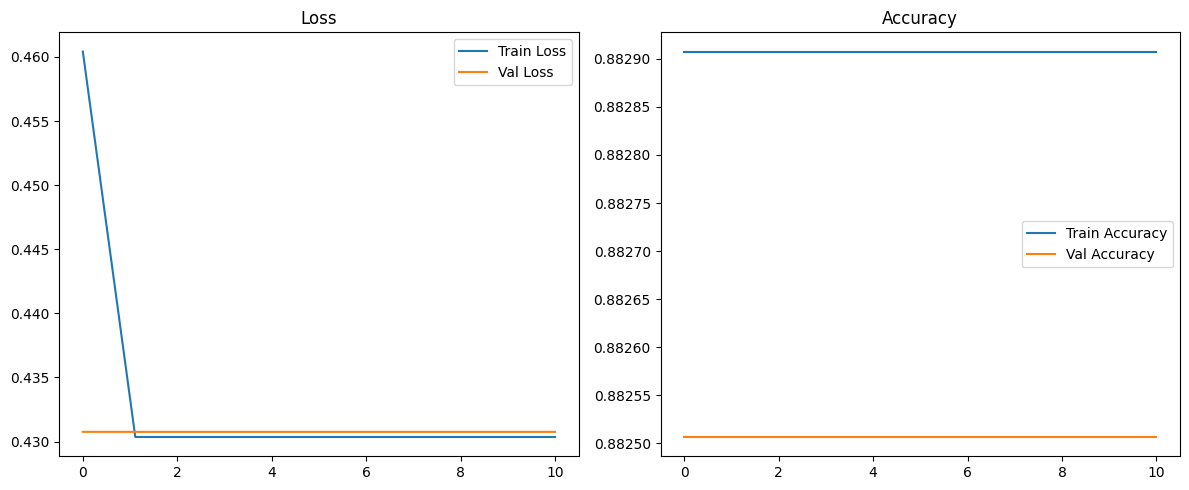

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7098
           1       0.00      0.00      0.00       945

    accuracy                           0.88      8043
   macro avg       0.44      0.50      0.47      8043
weighted avg       0.78      0.88      0.83      8043



In [12]:
result6 = eval_net(dataset_name, 'model6')

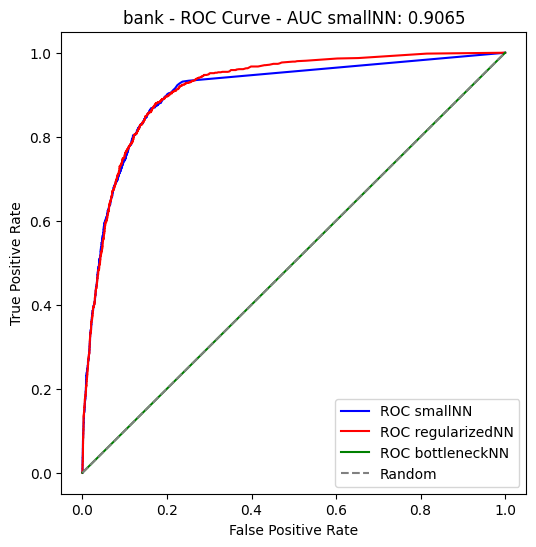

In [13]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])
    
roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])
    
roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve - AUC smallNN: {roc4:.4f}')
plt.plot(fpr4, tpr4, color='blue', label='ROC smallNN')
plt.plot(fpr5, tpr5, color='red', label='ROC regularizedNN')
plt.plot(fpr6, tpr6, color='green', label='ROC bottleneckNN')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## **BEANS**

In [25]:
dataset_name = "beans"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(10888, 7) (2223, 7) (500, 7)


### Beans - SmallNN

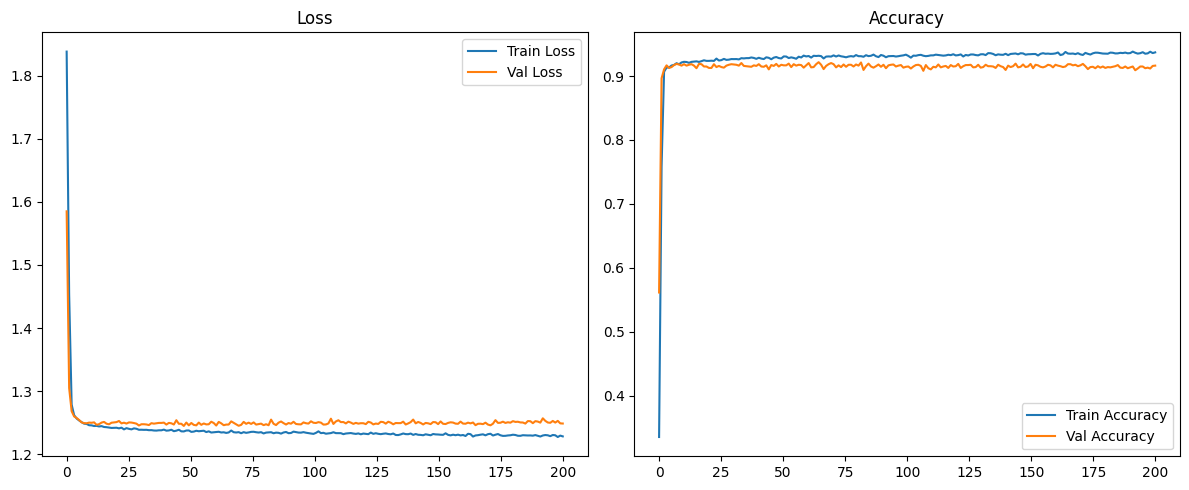

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       212
           1       1.00      0.99      0.99        71
           2       0.91      0.94      0.93       263
           3       0.90      0.93      0.91       589
           4       0.99      0.95      0.97       314
           5       0.92      0.95      0.94       330
           6       0.87      0.85      0.86       444

    accuracy                           0.92      2223
   macro avg       0.93      0.92      0.93      2223
weighted avg       0.92      0.92      0.92      2223



In [26]:
result4 = eval_net(dataset_name, 'model4')

### Beans - RegularizedNN

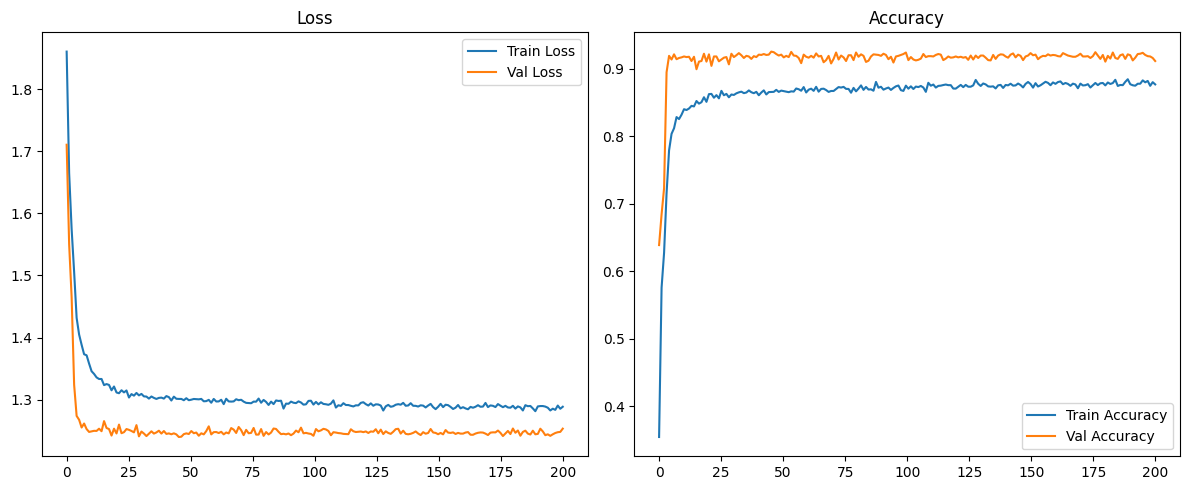

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       212
           1       1.00      0.97      0.99        71
           2       0.91      0.89      0.90       263
           3       0.93      0.89      0.91       589
           4       0.98      0.95      0.96       314
           5       0.93      0.95      0.94       330
           6       0.84      0.89      0.86       444

    accuracy                           0.91      2223
   macro avg       0.92      0.92      0.92      2223
weighted avg       0.91      0.91      0.91      2223



In [27]:
result5 = eval_net(dataset_name, 'model5')

### Beans - BottleneckNN

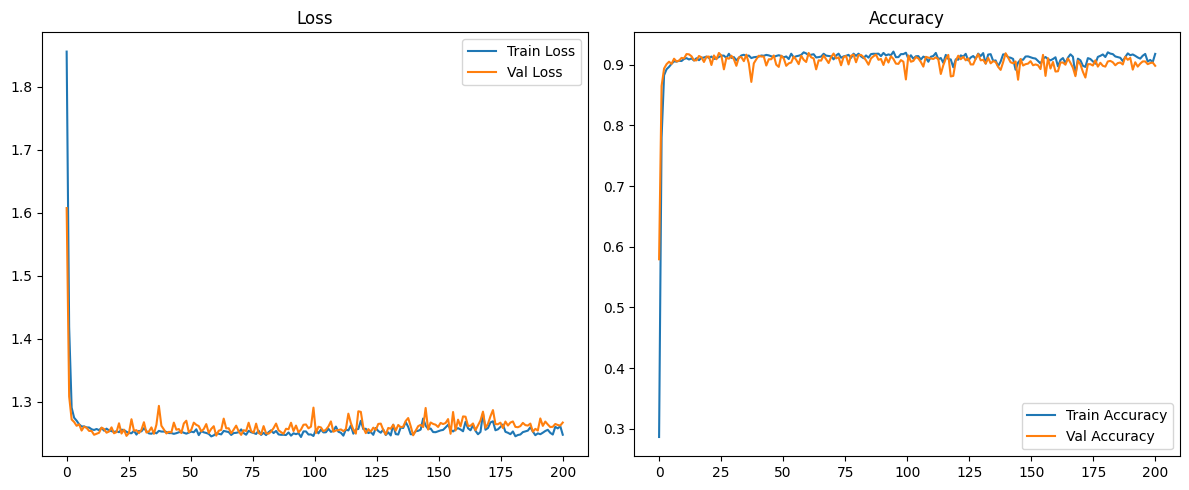

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       212
           1       1.00      0.92      0.96        71
           2       0.83      0.96      0.89       263
           3       0.92      0.88      0.90       589
           4       0.97      0.91      0.94       314
           5       0.94      0.93      0.94       330
           6       0.84      0.85      0.84       444

    accuracy                           0.90      2223
   macro avg       0.91      0.90      0.91      2223
weighted avg       0.90      0.90      0.90      2223



In [28]:
result6 = eval_net(dataset_name, 'model6')

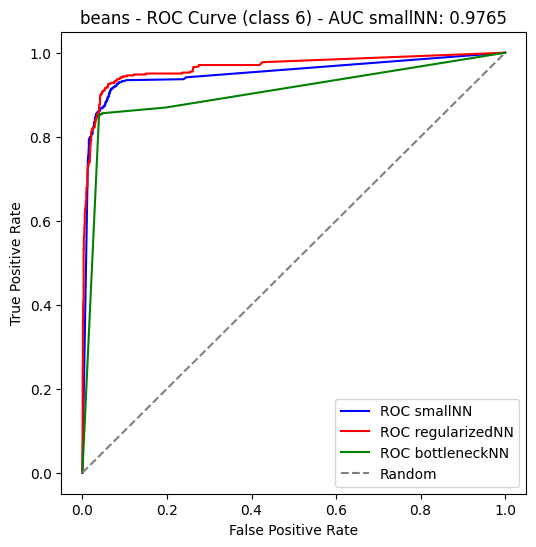

In [40]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0], multi_class='ovr')
roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0], multi_class='ovr')
roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0], multi_class='ovr')

class_idx = 6 # roc curve for each class

fpr4, tpr4, _ = roc_curve(y_val_labels == class_idx, result4['pred_proba'][0][:, class_idx])
fpr5, tpr5, _ = roc_curve(y_val_labels == class_idx, result5['pred_proba'][0][:, class_idx])
fpr6, tpr6, _ = roc_curve(y_val_labels == class_idx, result6['pred_proba'][0][:, class_idx])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve (class {class_idx}) - AUC smallNN: {roc4:.4f}')
plt.plot(fpr4, tpr4, color='blue', label='ROC smallNN')
plt.plot(fpr5, tpr5, color='red', label='ROC regularizedNN')
plt.plot(fpr6, tpr6, color='green', label='ROC bottleneckNN')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## **CANCER**

In [19]:
dataset_name = "cancer"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(397, 15) (121, 15) (50, 15)


### Cancer - SmallNN

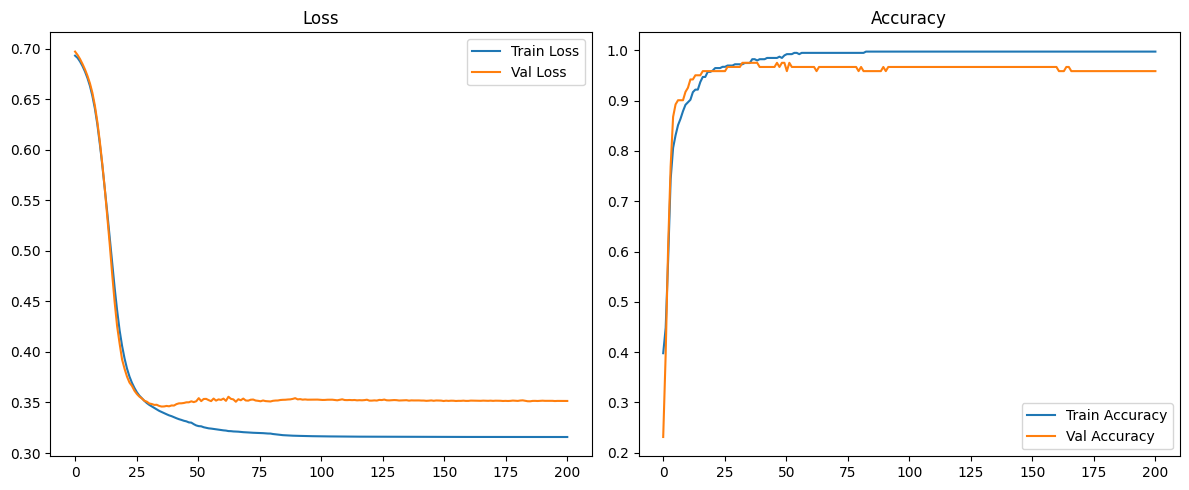

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        91
           1       0.88      0.97      0.92        30

    accuracy                           0.96       121
   macro avg       0.93      0.96      0.95       121
weighted avg       0.96      0.96      0.96       121



In [20]:
result4 = eval_net(dataset_name, 'model4')

### Cancer - RegularizedNN

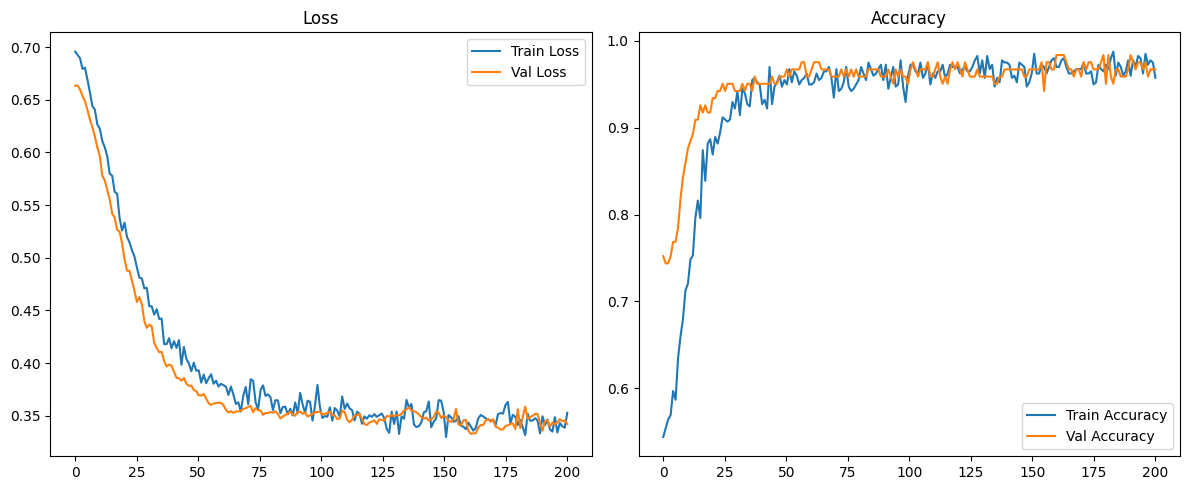

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        91
           1       0.93      0.93      0.93        30

    accuracy                           0.97       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.97      0.97      0.97       121



In [21]:
result5 = eval_net(dataset_name, 'model5')

### Cancer - BottleneckNN

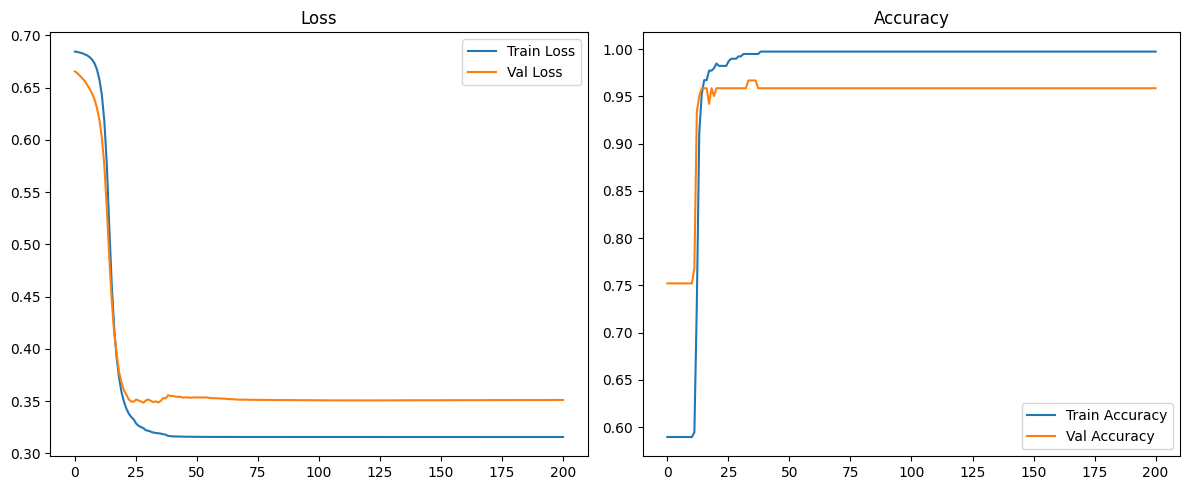

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        91
           1       0.90      0.93      0.92        30

    accuracy                           0.96       121
   macro avg       0.94      0.95      0.95       121
weighted avg       0.96      0.96      0.96       121



In [22]:
result6 = eval_net(dataset_name, 'model6')

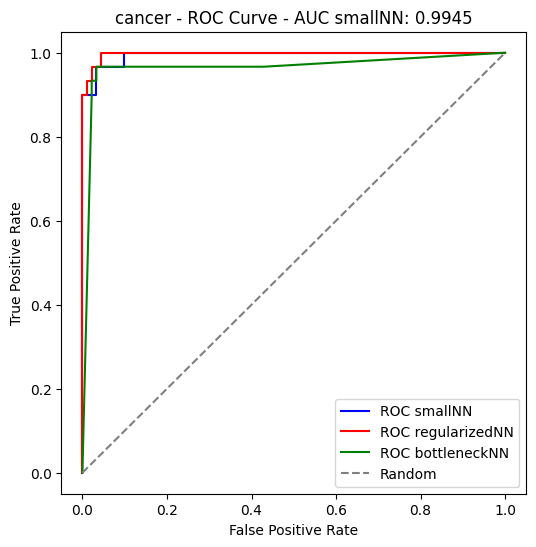

In [23]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])
    
roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])
    
roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

plt.figure(figsize=(6,6))
plt.title(f'{dataset_name} - ROC Curve - AUC smallNN: {roc4:.4f}')
plt.plot(fpr4, tpr4, color='blue', label='ROC smallNN')
plt.plot(fpr5, tpr5, color='red', label='ROC regularizedNN')
plt.plot(fpr6, tpr6, color='green', label='ROC bottleneckNN')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## **HELOC**

In [ ]:
model_dict = joblib.load(f"./load/nets/model_{dataset_name}_dict.joblib")
print(model_dict)